# Connection: event source、视图与运行时投递

这个例子与 `synapse.ipynb` 配对：`synapse.ipynb` 负责创建 postsynaptic dynamical entities；这里从已经存在的 `SynapseView` 出发，只讨论事件源如何通过 connection 驱动它们。

底层关系固定为：`EventSource -> Connection -> Synapse`。source 产生事件，connection 保存 routing、`weight` 和 `delay`，synapse 保存 `tau`、`e`、`g` 等动力学参数和状态。

In [1]:
import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import braincell
from braincell import mech
from braincell.filter import AllRegion, at

brainstate.environ.set(precision=64)

## 1. 三类对象

| 层 | 用户对象 | 后台内容 | 主要职责 |
|---|---|---|---|
| source | `EventSource` / `EventSourceView` | schedule 或 live detector | 产生离散事件 |
| routing | `ConnectionView` | private columnar store | 对齐 source/synapse，保存 `weight`、`delay` |
| target | `Synapse` / `SynapseView` / runtime node | logical store 与按 type 合并的 runtime SoA | 消费 event payload，更新 postsynaptic state |

`connect(...)` 接受具体 source owner/view 和具体 `SynapseView`，不接受尚未放置的 `Synapse` 声明。所有 view 都是保序、保重复的轻量索引，不复制底层参数或状态。

## 2. 构建真实的 10-CV HH population

与 `synapse.ipynb` 一样，morphology 是一个 soma 和两条 dendrite；`CVPerBranchList((1, 4, 5))` 产生 10 个 CV。

In [2]:
def build_morphology():
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type="soma",
    )
    dend_a = braincell.Branch.from_lengths(
        lengths=[160.0] * u.um, radii=[2.0, 1.0] * u.um, type="basal_dendrite",
    )
    dend_b = braincell.Branch.from_lengths(
        lengths=[220.0] * u.um, radii=[2.5, 0.8] * u.um, type="apical_dendrite",
    )
    morphology = braincell.Morphology.from_root(soma, name="soma")
    morphology.soma.dend_a = dend_a
    morphology.soma.dend_b = dend_b
    return morphology


def build_hh_population(name, size):
    cell = braincell.Cell(
        build_morphology(),
        cv_policy=braincell.CVPerBranchList((1, 4, 5)),
        pop_size=(size,),
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        solver="staggered",
        name=name,
    )
    cell.paint(
        AllRegion(),
        mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * (u.uF / u.cm**2),
            axial_resistivity=100.0 * (u.ohm * u.cm),
        ),
        mech.Ion("SodiumFixed", E=50.0 * u.mV),
        mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        mech.Channel("Na_HH1952", g_max=120.0 * (u.mS / u.cm**2)),
        mech.Channel("K_HH1952", g_max=36.0 * (u.mS / u.cm**2)),
        mech.Channel("IL", g_max=0.3 * (u.mS / u.cm**2), E=-54.387 * u.mV),
    )
    assert cell.n_cv == 10
    return cell

## 3. 先放置 target，再建立 connection

下面四组 `ExpSyn` 只是为了把四种 endpoint 对齐方式隔离开。它们虽然会在初始化后合并进同一个 `synapse:ExpSyn` runtime SoA，但各自仍可通过 name 得到稳定的 `SynapseView`。

In [3]:
post = build_hh_population("routing_target", size=4)

zip_syn = mech.SynapseSpec("ExpSyn", name="zip_syn", tau=2.0 * u.ms, e=0.0 * u.mV)
fanout_syn = mech.SynapseSpec("ExpSyn", name="fanout_syn", tau=2.0 * u.ms, e=0.0 * u.mV)
fanin_syn = mech.SynapseSpec("ExpSyn", name="fanin_syn", tau=2.0 * u.ms, e=0.0 * u.mV)
explicit_syn = mech.SynapseSpec("ExpSyn", name="explicit_syn", tau=2.0 * u.ms, e=0.0 * u.mV)

post.place(at("dend_a", 0.25), zip_syn)
post.place(at("dend_a", 0.50), fanout_syn)
post[0].place(at("dend_b", 0.50), fanin_syn)
post.place(at("dend_b", 0.75), explicit_syn)

targets = post.synapses
targets

SynapseView(target=Cell(name='routing_target'), size=13, synapse_type=ExpSyn, names={'zip_syn': 4, 'fanout_syn': 4, 'fanin_syn': 1, 'explicit_syn': 4}, parameters=('e', 'tau'))

### 对齐规则

设最终 connection 行数为 `C`：

- source 和 synapse 等长：逐行 zip；
- source 长度为 1：fan-out 到全部 synapses；
- synapse 长度为 1：全部 sources fan-in 到同一 target；
- 其他映射：两侧用保重复索引显式展开成相同长度。

`weight` 与 `delay` 在对齐后按 `C` 行广播，只接受 scalar 或 `(C,)`。`ExpSyn`/`Exp2Syn` 声明消费 conductance payload，因此 `weight` 必须具有 conductance 量纲；默认是 `1 uS`，允许负值。

In [4]:
stim4 = braincell.NetStim(size=4, start=50.0 * u.ms, number=1, name="stim4")
stim1 = braincell.NetStim(size=1, start=50.0 * u.ms, number=1, name="stim1")

zipped = braincell.connect(
    "zip_input", source=stim4, synapse=targets["zip_syn"],
    weight=np.asarray([0.10, 0.20, 0.30, 0.40]) * u.uS,
)
fanout = braincell.connect(
    "fanout_input", source=stim1, synapse=targets["fanout_syn"], weight=0.15 * u.uS,
)
fanin = braincell.connect(
    "fanin_input", source=stim4, synapse=targets["fanin_syn"], delay=np.arange(4) * u.ms,
)

# 任意多对多关系由两边同长度的重复 view 明确表达。
explicit = braincell.connect(
    "explicit_input",
    source=stim4[[2, 0, 2, 1]],
    synapse=targets["explicit_syn"][[1, 2, 1, 0]],
    weight=np.asarray([0.10, 0.20, -0.05, 0.30]) * u.uS,
    delay=np.asarray([0.0, 0.5, 1.0, 1.5]) * u.ms,
)

### Cell 级统一总览与筛选

`post.connections` 是一张统一的 routing-row view。字符串索引选择一次命名的 `connect()`；其余筛选和布尔 mask 都返回可继续组合的 `ConnectionView`。

In [5]:
post.connections

assert post.connections.connect_names == (
    "zip_input", "fanout_input", "fanin_input", "explicit_input",
)
assert len(post.connections["zip_input"]) == 4
assert len(post.connections.by_source_name("stim4")) == 12
assert len(post.connections.by_synapse_name("explicit_syn")) == 4

delayed = post.connections[post.connections.delay > 0.0 * u.ms]
delayed

ConnectionView(cell=CellView(name='routing_target', cells=[0, 2, 1]), rows=6, connects=2)
  fanin_input: NetStim(stim4) -> ExpSyn(fanin_syn), rows=3
  explicit_input: NetStim(stim4) -> ExpSyn(explicit_syn), rows=3

In [6]:
def connection_table(view):
    weight = view.weight
    return pd.DataFrame({
        "connection_id": view.id,
        "source_id": view.source_index,
        "synapse_id": view.synapse_id,
        "synapse_cell": view.synapse.population_index,
        "weight_uS": np.nan if weight is None else weight.to_decimal(u.uS),
        "delay_ms": view.delay.to_decimal(u.ms),
    })

alignment_summary = pd.DataFrame({
    "case": ["zip", "fan-out", "fan-in", "explicit duplicate views"],
    "rows": [len(zipped), len(fanout), len(fanin), len(explicit)],
    "source_ids": [view.source_index.tolist() for view in (zipped, fanout, fanin, explicit)],
    "synapse_cells": [view.synapse.population_index.tolist() for view in (zipped, fanout, fanin, explicit)],
})

np.testing.assert_array_equal(zipped.source_index, [0, 1, 2, 3])
np.testing.assert_array_equal(fanout.source_index, [0, 0, 0, 0])
np.testing.assert_array_equal(fanin.synapse.population_index, [0, 0, 0, 0])
np.testing.assert_array_equal(explicit.synapse.population_index, [1, 2, 1, 0])
alignment_summary

,case,rows,source_ids,synapse_cells
0,zip,4,"[0, 1, 2, 3]","[0, 1, 2, 3]"
1,fan-out,4,"[0, 0, 0, 0]","[0, 1, 2, 3]"
2,fan-in,4,"[0, 1, 2, 3]","[0, 0, 0, 0]"
3,explicit duplicate views,4,"[2, 0, 2, 1]","[1, 2, 1, 0]"


In [7]:
connection_table(explicit)

,connection_id,source_id,synapse_id,synapse_cell,weight_uS,delay_ms
0,12,2,13,1,0.10,0.0
1,13,0,14,2,0.20,0.5
2,14,2,13,1,-0.05,1.0
3,15,1,12,0,0.30,1.5


## 4. ConnectionView 修改、切片与删除

`ConnectionView` 与 `SynapseView` 一样只保存稳定 ID。`connections["name"]` 按 connect 名称选择，数值、切片和布尔数组始终选择 routing rows。初始化前，`.set()` 修改选中行的 `weight`/`delay`；`.remove()` 留下不复用的 ID 空洞。初始化后 topology 已固定，不能再增删或修改声明列。

In [8]:
selected = explicit[[2, 0]]
selected.set(
    weight=np.asarray([0.25, -0.10]) * u.uS,
    delay=np.asarray([2.0, 0.25]) * u.ms,
)
removed_id = int(explicit[1].id[0])
explicit[1].remove()
later = braincell.connect(
    "later_input", source=stim1, synapse=targets["explicit_syn"][3], weight=0.05 * u.uS,
)

assert removed_id not in explicit.id
assert int(later.id[0]) > removed_id
connection_table(explicit)

,connection_id,source_id,synapse_id,synapse_cell,weight_uS,delay_ms
0,12,2,13,1,-0.10,0.25
1,14,2,13,1,0.25,2.00
2,15,1,12,0,0.30,1.50


## 5. Scheduled sources: `EventTable`、`EventSequence` 与 `NetStim`

`EventTable` 是统一的扁平 schedule：每行只有 `source_index`、`time` 和稳定 `event_id`。`EventSequence` 直接使用这张表；`NetStim.events` 把生成后的 schedule 暴露成同一格式。

In [9]:
sequence = braincell.EventSequence(
    size=4,
    events=braincell.EventTable(
        source_index=[0, 1, 2, 3],
        time=np.asarray([1.0, 1.5, 2.0, 2.5]) * u.ms,
    ),
    name="explicit_schedule",
)

schedule_table = pd.DataFrame({
    "event_id": sequence.events.event_id,
    "source_id": sequence.events.source_index,
    "time_ms": sequence.events.time.to_decimal(u.ms),
})
schedule_table

,event_id,source_id,time_ms
0,0,0,1.0
1,1,1,1.5
2,2,2,2.0
3,3,3,2.5


In [10]:
scheduled_post = build_hh_population("scheduled_post", size=4)
scheduled_syn = mech.SynapseSpec("ExpSyn", name="scheduled", tau=3.0 * u.ms, e=0.0 * u.mV)
scheduled_post.place(
    at("dend_a", 0.50),
    scheduled_syn,
    mech.MechanismProbe(name="g_scheduled", mechanism="scheduled", field="g"),
)
scheduled_connection = braincell.connect(
    "scheduled_input",
    source=sequence,
    synapse=scheduled_post.synapses[scheduled_syn],
    weight=np.asarray([0.10, 0.20, 0.30, 0.40]) * u.uS,
    delay=np.asarray([0.0, 0.25, 0.50, 0.75]) * u.ms,
)
scheduled_result = scheduled_post.run(dt=0.025 * u.ms, duration=4.0 * u.ms)
scheduled_g = np.asarray(scheduled_result.traces["g_scheduled"].to_decimal(u.uS))
first_nonzero = np.asarray([np.flatnonzero(scheduled_g[:, i] > 0.0)[0] for i in range(4)])
first_arrival_ms = scheduled_result.time[first_nonzero].to_decimal(u.ms)
expected_arrival_ms = np.asarray([1.0, 1.75, 2.5, 3.25])
np.testing.assert_allclose(first_arrival_ms, expected_arrival_ms, atol=1e-12)
pd.DataFrame({
    "source_id": np.arange(4),
    "event_ms": [1.0, 1.5, 2.0, 2.5],
    "delay_ms": scheduled_connection.delay.to_decimal(u.ms),
    "observed_arrival_ms": first_arrival_ms,
})

,source_id,event_ms,delay_ms,observed_arrival_ms
0,0,1.0,0.00,1.00
1,1,1.5,0.25,1.75
2,2,2.0,0.50,2.50
3,3,2.5,0.75,3.25


## 6. Live sources: canonical cell spike 与局部 voltage crossing

`cell.event_outputs["spike"]` 是 canonical live source：每个 cell 一行，读取 root midpoint CV 上由 `Cell.V_th` 产生的 spike。它不是 spike history，也不复制 dense CV signal。

`VoltageCrossingSource` 是独立 detector，可选择其他 location、threshold 和方向。这里用同一个 presynaptic cell 的 dendrite 电压、较低阈值驱动第二个突触，从而验证它与 canonical spike 是两个不同 source。

In [11]:
pre = build_hh_population("live_pre", size=1)
live_post = build_hh_population("live_post", size=1)
pre.place(
    at("soma", 0.50),
    mech.CurrentClamp(delay=1.0 * u.ms, durations=0.10 * u.ms, amplitudes=1.0 * u.nA),
)

canonical_syn = mech.SynapseSpec("ExpSyn", name="canonical_spike", tau=2.0 * u.ms, e=0.0 * u.mV)
local_syn = mech.SynapseSpec("ExpSyn", name="local_crossing", tau=2.0 * u.ms, e=0.0 * u.mV)
live_post.place(
    at("dend_a", 0.25),
    canonical_syn,
    mech.MechanismProbe(name="g_canonical", mechanism="canonical_spike", field="g"),
)
live_post.place(
    at("dend_a", 0.75),
    local_syn,
    mech.MechanismProbe(name="g_local", mechanism="local_crossing", field="g"),
)

canonical_source = pre.event_outputs["spike"]
local_source = braincell.VoltageCrossingSource(
    pre, location=at("dend_a", 0.25), threshold=-40.0 * u.mV, name="dendritic_-40mV",
)
braincell.connect(
    "canonical_spike_input",
    source=canonical_source,
    synapse=live_post.synapses[canonical_syn],
    weight=0.10 * u.uS,
)
braincell.connect(
    "local_crossing_input",
    source=local_source,
    synapse=live_post.synapses[local_syn],
    weight=0.10 * u.uS,
)

live_network = braincell.Network(name="live_sources")
live_network.add_population("pre", pre)
live_network.add_population("post", live_post)
live_result = live_network.run(dt=0.025 * u.ms, duration=5.0 * u.ms)

In [12]:
time_ms = live_result.time.to_decimal(u.ms)
pre_spike = np.asarray(live_result.spikes["pre"]).reshape(len(time_ms), -1).any(axis=1)
g_canonical = np.asarray(live_result.traces["post"]["g_canonical"].to_decimal(u.uS)).reshape(-1)
g_local = np.asarray(live_result.traces["post"]["g_local"].to_decimal(u.uS)).reshape(-1)

spike_row = int(np.flatnonzero(pre_spike)[0])
canonical_row = int(np.flatnonzero(g_canonical > 0.0)[0])
local_row = int(np.flatnonzero(g_local > 0.0)[0])
assert canonical_row == spike_row  # delay=0: source crossing 所在 boundary 写入 target state
assert local_row <= canonical_row

live_event_summary = pd.DataFrame({
    "source": ["VoltageCrossingSource(dend_a, -40 mV)", "cell.event_outputs['spike'] (root, V_th=0 mV)"],
    "first_target_event_ms": [time_ms[local_row], time_ms[canonical_row]],
})
live_event_summary

,source,first_target_event_ms
0,"VoltageCrossingSource(dend_a, -40 mV)",4.3500000000000005
1,"cell.event_outputs['spike'] (root, V_th=0 mV)",4.875


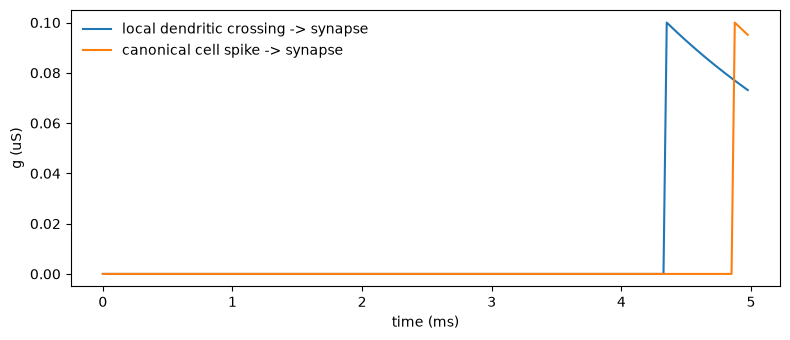

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(time_ms, g_local, label="local dendritic crossing -> synapse")
ax.plot(time_ms, g_canonical, label="canonical cell spike -> synapse")
ax.set(xlabel="time (ms)", ylabel="g (uS)")
ax.legend(frameon=False)
fig.tight_layout()

## 结论

- `EventSourceView` 与 `SynapseView` 先对齐，`connect()` 再产生一行一个 routing record 的 `ConnectionView`。
- connection 的 `weight`/`delay` 与 synapse 的 `tau`/`e`/`g` 分属不同 owner。多个 connections 可以指向同一个 synapse。
- 等长 zip、单端广播和显式重复 views 覆盖底层 general mapping；高级连接规则只需 lowering 到同一 row 格式。
- `EventSequence`/`NetStim` 是 scheduled sources；canonical cell spike 与 `VoltageCrossingSource` 是 live sources。
- `delay=0` 在 source crossing 所在 boundary 更新 synapse event state；正 delay 量化后由延迟状态投递。